I will be using this notebook as a Slide Deck for my research.

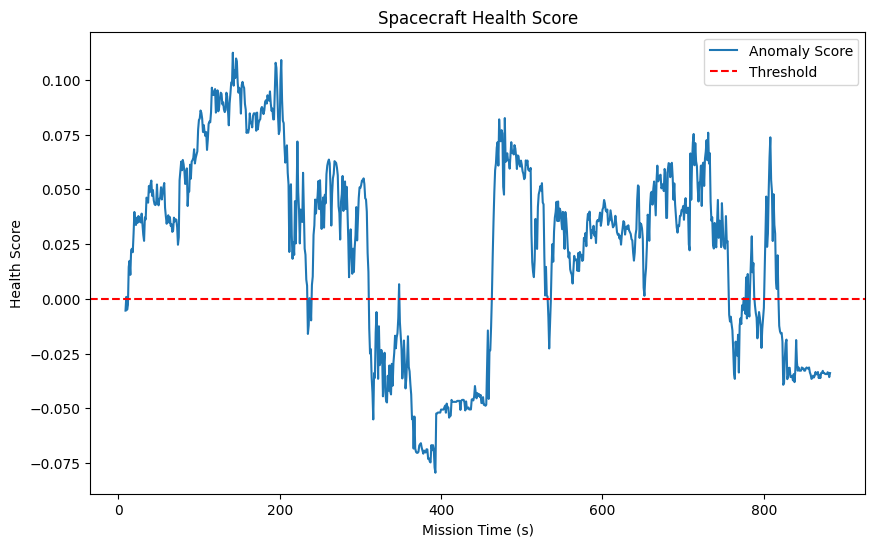

In [2]:
import pandas as pd
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt

train_df = pd.read_csv("../datasets/3_clean.csv")
test_df = pd.read_csv("../datasets/o2_leak.csv")

# then select the features
features = ["pitch", "y_pos", "z_pos", "o2_level", "co2_level", "total_drain", "solar_input", "is_scrubber_on", "is_engine_on"]
X_train = train_df[features]

# initialize Isolation Forest model
model = IsolationForest(contamination=0.01, random_state=42)

# train model
model.fit(X_train)

X_test = test_df[features]
test_df['scores'] = model.decision_function(X_test)
test_df['anomaly_pred'] = model.predict(X_test)

# visualize results
plt.figure(figsize=(10,6))
plt.plot(test_df['timestamp'], test_df['scores'], label='Anomaly Score')
plt.axhline(y=0, color='r', linestyle='--', label='Threshold')
plt.title("Spacecraft Health Score")
plt.xlabel("Mission Time (s)")
plt.ylabel("Health Score")
plt.legend()
plt.show()

In [ ]:
print(test_df[test_df['scores'] < 0][['timestamp', 'o2_level', 'scores', 'anomaly_pred']].head(50))

TypeError: '<' not supported between instances of 'str' and 'int'